In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
from matplotlib import pyplot as plt
import sys, os
sys.path.append("../../src/")


import scipy.stats as stats
from tqdm import tqdm
from fb_inhibition import FeedbackInhibition

In [3]:
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['legend.frameon'] = False

In [4]:
net = FeedbackInhibition(inh="on", seed=100)

setting seed: 100


In [5]:
net.run()


100%|██████████| 840/840 [02:24<00:00,  5.81it/s]


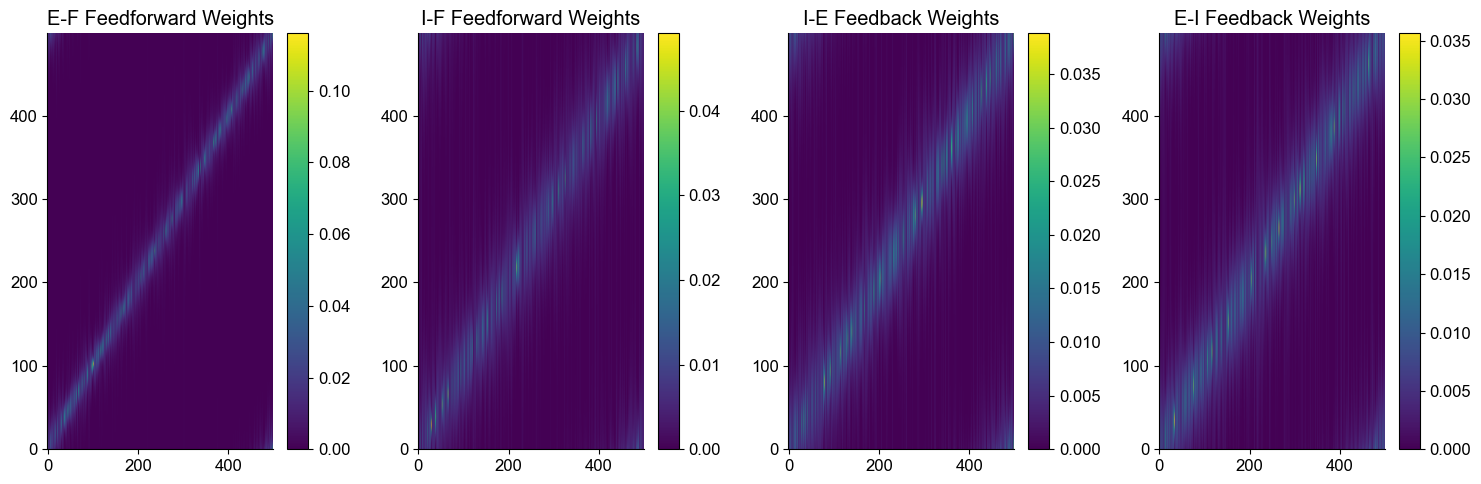

In [6]:
net.plot_initial_weight_matrices()

In [7]:
tuning_curves = net.estimate_tuning_curves_at_day(8)

In [8]:
# Estimate drift

drift_mag, drift_rate, convergence = net.get_metrics(net.N, net.n_days, net.theta_stim, net.POs)


<>:27: SyntaxWarning: invalid escape sequence '\;'
<>:27: SyntaxWarning: invalid escape sequence '\;'
/var/folders/g6/7nyb4bzj60n8q754q7qp7z200000gn/T/ipykernel_29449/652151206.py:27: SyntaxWarning: invalid escape sequence '\;'
  axs[2].set_ylabel('convergence $ \; [\degree]$')
/var/folders/g6/7nyb4bzj60n8q754q7qp7z200000gn/T/ipykernel_29449/652151206.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[0].legend(frameon=False, fontsize=8)
/var/folders/g6/7nyb4bzj60n8q754q7qp7z200000gn/T/ipykernel_29449/652151206.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[1].legend(frameon=False, fontsize=8)
/var/folders/g6/7nyb4bzj60n8q754q7qp7z200000gn/T/ipykernel_29449/652151206.py:29: UserWarning: No artists with labels found to put 

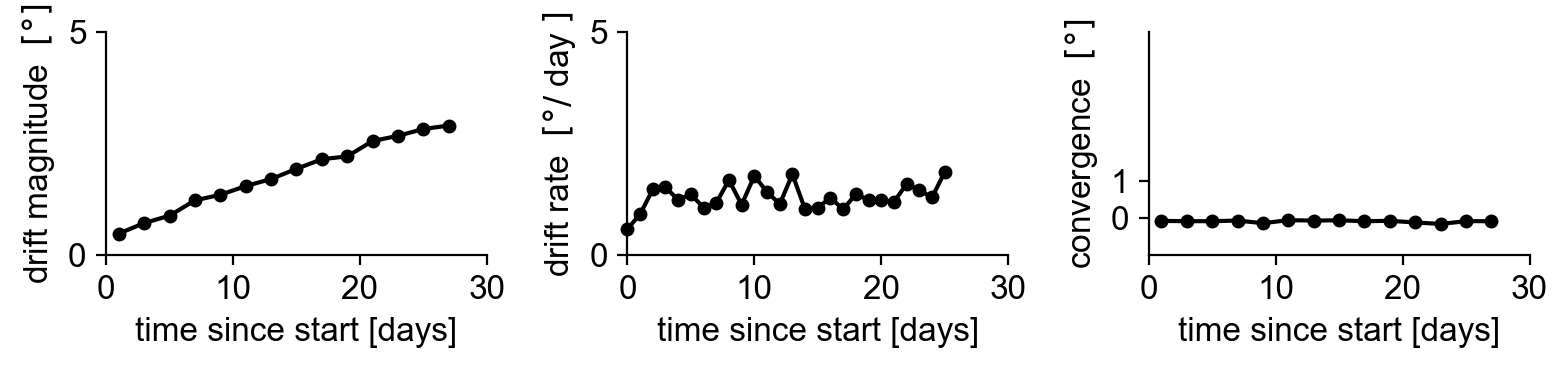

In [9]:
eo = 2


fig, axs = plt.subplots(1, 3, figsize=(8, 2), dpi=200)
axs[0].plot(np.arange(1, net.n_days)[::eo], np.median(drift_mag, axis=1)[:-1][::eo], c='black', ls='-', marker='o', ms=4, clip_on=False)
# axs[0].plot(np.arange(1, net_non_varying.n_days)[::eo], np.median(drift_mag_non_varying, axis=1)[:-1][::eo], c='green', ls='-', marker='o', ms=4, label='Baseline', clip_on=False)
axs[0].set_ylim([0, 5]); axs[0].set_yticks([0, 5])
axs[0].set_xlabel('time since start [days]')
axs[0].set_ylabel(r'drift magnitude $ \; [\degree]$')
axs[0].set_xlim(0, 30)
axs[0].legend(frameon=False, fontsize=8)


axs[1].plot(np.mean(drift_rate, axis=1)[:-1], c='black', ls='-', marker='o', ms=4, clip_on=False)
# axs[1].plot(np.mean(drift_rate_non_varying, axis=1)[:-1], c='green', ls='-', marker='o', ms=4, label='Baseline', clip_on=False)
axs[1].set_ylim([0, 5]); axs[1].set_yticks([0,
                                             5])
axs[1].set_xlabel('time since start [days]')
axs[1].set_ylabel(r'drift rate $ \; [\degree / $ day $]$')
axs[1].set_xlim(0, 30)
axs[1].legend(frameon=False, fontsize=8)

axs[2].plot(np.arange(1, net.n_days)[::eo], np.median(convergence, axis=1)[::eo], c='black', ls='-', marker='o', ms=4, clip_on=False)
# axs[2].plot(np.arange(1, net_non_varying.n_days)[::eo], np.median(convergence_non_varying, axis=1)[::eo], c='green', ls='-', marker='o', ms=4, label='Baseline', clip_on=False)
axs[2].set_ylim([-1, 5]); axs[2].set_yticks([0, 1])
axs[2].set_xlabel('time since start [days]')
axs[2].set_ylabel('convergence $ \; [\degree]$')
axs[2].set_xlim(0, 30)
axs[2].legend(frameon=False, fontsize=8)

fig.tight_layout()
fig.show()

### Population activity

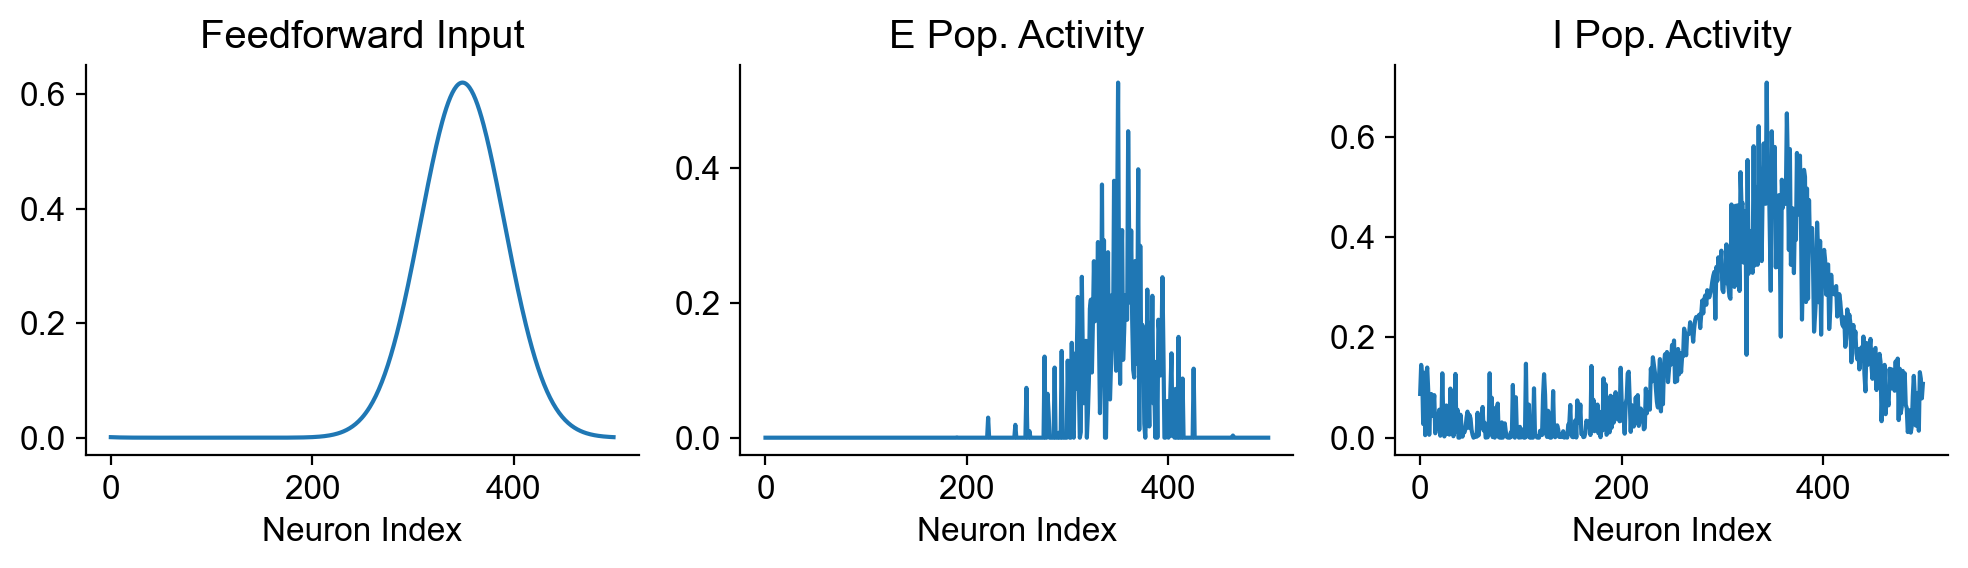

In [11]:
net.plot_pop_activity_at_day(15, net.theta_stim)

### Tuning curves across days